# Project Title: 
## PowerCo Customer Churn & Price Sensitivity Analysis

PowerCo is a major gas and electricity utility that supplies to small and medium sized enterprises.

 The company suspects that price sensitivity is driving their customers to switch providers.  
 The project task is to investigate the reason for customer churn.

 We'll dig into the data, develop hypotheses, build predictive models, and translate insights into strategic recommendations.


***Note:** The client strongly believes that the major cause for churn (among others) is that customers have become more “sensitive” to the price and are opting toward low-cost providers. We will need to validate or disprove this idea that price is the critical factor.*

Price sensitivity is the degree to which customer behaviors change in response to a change in price. In other words, how much do PowerCo’s customers react when prices go up?

Sensitivity is often quantified using the price elasticity of demand formula which is [% change in quantity demanded / % change in price].

#### Provided Dataset:  
**client_data.csv** : containing Customer data such as usage, sign up date, forecasted usage  
**price_data.csv** : containing variable and fixed pricing data at different points in time


# Exploratory Data Analysis

## Import packages

In [ ]:
# install requirements
%pip install -r "../requirements.txt"

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Shows plots in jupyter notebook
%matplotlib inline

# Set plot style
sns.set(color_codes=True)

---

## Loading data with Pandas

We need to load `client_data.csv` and `price_data.csv` into individual dataframes so that we can easily work with them.

In [2]:
root = Path('..')
data_path = root/'data'
client_df = pd.read_csv(data_path/'client_data.csv')
price_df = pd.read_csv(data_path/'price_data.csv')

In [3]:
client_df.head(3)

,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,...,has_gas,imp_cons,margin_gross_pow_ele,margin_net_pow_ele,nb_prod_act,net_margin,num_years_antig,origin_up,pow_max,churn
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.00,...,t,0.0,25.44,25.44,2,678.99,3,lxidpiddsbxsbosboudacockeimpuepw,43.648,1
1,d29c2c54acc38ff3c0614d0a653813dd,MISSING,4660,0,0,2009-08-21,2016-08-30,2009-08-21,2015-08-31,189.95,...,f,0.0,16.38,16.38,1,18.89,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.800,0
2,764c75f661154dac3a6c254cd082ea7d,foosdfpfkusacimwkcsosbicdxkicaua,544,0,0,2010-04-16,2016-04-16,2010-04-16,2015-04-17,47.96,...,f,0.0,28.60,28.60,1,6.60,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.856,0


In [4]:
price_df.head(3)

,id,price_date,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
0,038af19179925da21a25619c5a24b745,2015-01-01,0.151367,0.0,0.0,44.266931,0.0,0.0
1,038af19179925da21a25619c5a24b745,2015-02-01,0.151367,0.0,0.0,44.266931,0.0,0.0
2,038af19179925da21a25619c5a24b745,2015-03-01,0.151367,0.0,0.0,44.266931,0.0,0.0


In [5]:
#To check the number of columns and rows for both datasets
display(price_df.shape)
display(client_df.shape)

(193002, 8)

(14606, 26)

---

## Data Validation & Pre-Processing

It is useful to first understand the data that we're dealing with along with the data types of each column and unique values within the columns. The data types may dictate how we transform and engineer features.


### a). Client data Validation and Preprocessing



In [6]:
# To check the data types for Clients data
client_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14606 entries, 0 to 14605
Data columns (total 26 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              14606 non-null  str    
 1   channel_sales                   14606 non-null  str    
 2   cons_12m                        14606 non-null  int64  
 3   cons_gas_12m                    14606 non-null  int64  
 4   cons_last_month                 14606 non-null  int64  
 5   date_activ                      14606 non-null  str    
 6   date_end                        14606 non-null  str    
 7   date_modif_prod                 14606 non-null  str    
 8   date_renewal                    14606 non-null  str    
 9   forecast_cons_12m               14606 non-null  float64
 10  forecast_cons_year              14606 non-null  int64  
 11  forecast_discount_energy        14606 non-null  float64
 12  forecast_meter_rent_12m         14606 non-n

In [7]:
# To check the summary statistics 
client_df.describe()

,cons_12m,cons_gas_12m,cons_last_month,forecast_cons_12m,forecast_cons_year,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,forecast_price_pow_off_peak,imp_cons,margin_gross_pow_ele,margin_net_pow_ele,nb_prod_act,net_margin,num_years_antig,pow_max,churn
count,1.460600e+04,1.460600e+04,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000
mean,1.592203e+05,2.809238e+04,16090.269752,1868.614880,1399.762906,0.966726,63.086871,0.137283,0.050491,43.130056,152.786896,24.565121,24.562517,1.292346,189.264522,4.997809,18.135136,0.097152
std,5.734653e+05,1.629731e+05,64364.196422,2387.571531,3247.786255,5.108289,66.165783,0.024623,0.049037,4.485988,341.369366,20.231172,20.230280,0.709774,311.798130,1.611749,13.534743,0.296175
min,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,3.300000,0.000000
25%,5.674750e+03,0.000000e+00,0.000000,494.995000,0.000000,0.000000,16.180000,0.116340,0.000000,40.606701,0.000000,14.280000,14.280000,1.000000,50.712500,4.000000,12.500000,0.000000
50%,1.411550e+04,0.000000e+00,792.500000,1112.875000,314.000000,0.000000,18.795000,0.143166,0.084138,44.311378,37.395000,21.640000,21.640000,1.000000,112.530000,5.000000,13.856000,0.000000
75%,4.076375e+04,0.000000e+00,3383.000000,2401.790000,1745.750000,0.000000,131.030000,0.146348,0.098837,44.311378,193.980000,29.880000,29.880000,1.000000,243.097500,6.000000,19.172500,0.000000
max,6.207104e+06,4.154590e+06,771203.000000,82902.830000,175375.000000,30.000000,599.310000,0.273963,0.195975,59.266378,15042.790000,374.640000,374.640000,32.000000,24570.650000,13.000000,320.000000,1.000000


To gain insight into number of clients that have churned

In [8]:
# To check the Unique values per column
client_df.nunique()

id                                14606
channel_sales                         8
cons_12m                          11065
cons_gas_12m                       2112
cons_last_month                    4751
date_activ                         1796
date_end                            368
date_modif_prod                    2129
date_renewal                        386
forecast_cons_12m                 13993
forecast_cons_year                 4218
forecast_discount_energy             12
forecast_meter_rent_12m            3528
forecast_price_energy_off_peak      516
forecast_price_energy_peak          329
forecast_price_pow_off_peak          41
has_gas                               2
imp_cons                           7752
margin_gross_pow_ele               2391
margin_net_pow_ele                 2391
nb_prod_act                          10
net_margin                        11965
num_years_antig                      13
origin_up                             6
pow_max                             698


In [9]:
# Checking for duplicates
client_df.duplicated().sum()

np.int64(0)

### b). Price data Validation and Preprocessing


In [10]:
# To check the data types for Clients data
price_df.info() # Why float instead of int, there are some int amidst the floats

<class 'pandas.DataFrame'>
RangeIndex: 193002 entries, 0 to 193001
Data columns (total 8 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   id                  193002 non-null  str    
 1   price_date          193002 non-null  str    
 2   price_off_peak_var  193002 non-null  float64
 3   price_peak_var      193002 non-null  float64
 4   price_mid_peak_var  193002 non-null  float64
 5   price_off_peak_fix  193002 non-null  float64
 6   price_peak_fix      193002 non-null  float64
 7   price_mid_peak_fix  193002 non-null  float64
dtypes: float64(6), str(2)
memory usage: 11.8 MB


In [11]:
# To check the summary statistics
price_df.describe()

,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
count,193002.000000,193002.000000,193002.000000,193002.000000,193002.000000,193002.000000
mean,0.141027,0.054630,0.030496,43.334477,10.622875,6.409984
std,0.025032,0.049924,0.036298,5.410297,12.841895,7.773592
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.125976,0.000000,0.000000,40.728885,0.000000,0.000000
50%,0.146033,0.085483,0.000000,44.266930,0.000000,0.000000
75%,0.151635,0.101673,0.072558,44.444710,24.339581,16.226389
max,0.280700,0.229788,0.114102,59.444710,36.490692,17.458221


In [12]:
price_df.nunique()

id                    16096
price_date               12
price_off_peak_var     1853
price_peak_var         1189
price_mid_peak_var      711
price_off_peak_fix       66
price_peak_fix           31
price_mid_peak_fix       28
dtype: int64

In [13]:
# Checking for duplicates
price_df.duplicated().sum()

np.int64(0)

### c). Missingness and Null Inspection

In [14]:
client_df.isnull().sum()

id                                0
channel_sales                     0
cons_12m                          0
cons_gas_12m                      0
cons_last_month                   0
date_activ                        0
date_end                          0
date_modif_prod                   0
date_renewal                      0
forecast_cons_12m                 0
forecast_cons_year                0
forecast_discount_energy          0
forecast_meter_rent_12m           0
forecast_price_energy_off_peak    0
forecast_price_energy_peak        0
forecast_price_pow_off_peak       0
has_gas                           0
imp_cons                          0
margin_gross_pow_ele              0
margin_net_pow_ele                0
nb_prod_act                       0
net_margin                        0
num_years_antig                   0
origin_up                         0
pow_max                           0
churn                             0
dtype: int64

In [15]:
price_df.isnull().sum()

id                    0
price_date            0
price_off_peak_var    0
price_peak_var        0
price_mid_peak_var    0
price_off_peak_fix    0
price_peak_fix        0
price_mid_peak_fix    0
dtype: int64

<Axes: >

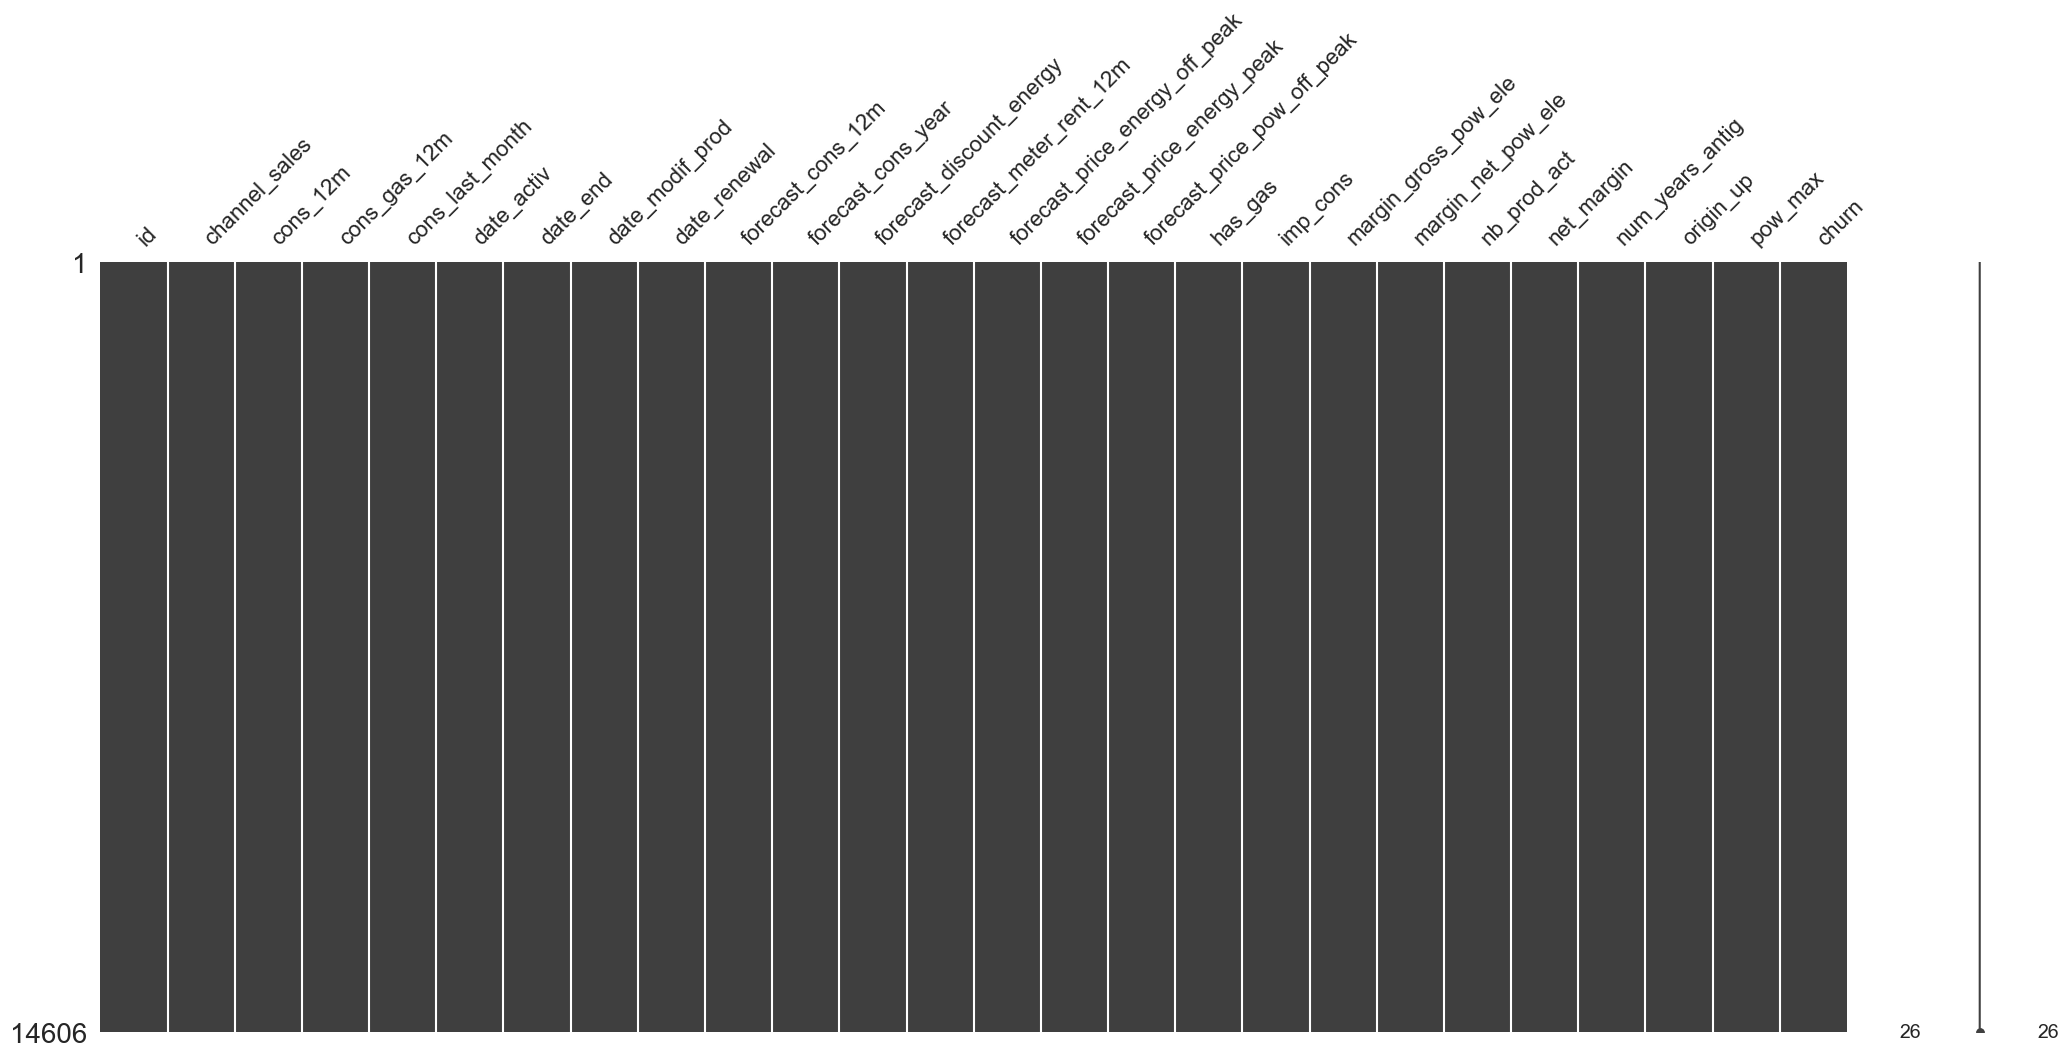

In [16]:
# Visual Missingness inspection
import missingno as msno

msno.matrix(client_df)


From the above data validation steps, it can be deduced that there are no missing or null values, but we can also see that all of the `datetime` related columns are not currently in datetime format while some Categorical columns like `['has_gas']` are stored as strings. We shall convert these to their appropriate datatypes.

#### Convert Columns to their correct Datatypes

In [17]:
# Convert Date columns to Datetime datatypes for both tables
# List of all date columns
date_columns = ['date_activ', 'date_end', 'date_modif_prod', 'date_renewal']

# Loop and convert each column
for col in date_columns:
    client_df[col] = pd.to_datetime(client_df[col])

price_df['price_date'] = pd.to_datetime(price_df['price_date'], format='%Y-%m-%d')

# Convert 't' to 1 (True) and 'f' to 0 (False) for '"has_gas"
client_df["has_gas"] = (
    client_df["has_gas"]
    .map({"t": 1, "f": 0})
    .astype("int8")
)

In [18]:
client_df['has_gas'].unique()

array([1, 0], dtype=int8)

---

## Exploratory Data Analysis



### Understanding the Target

In [19]:
client_df['churn'].value_counts()

churn
0    13187
1     1419
Name: count, dtype: int64

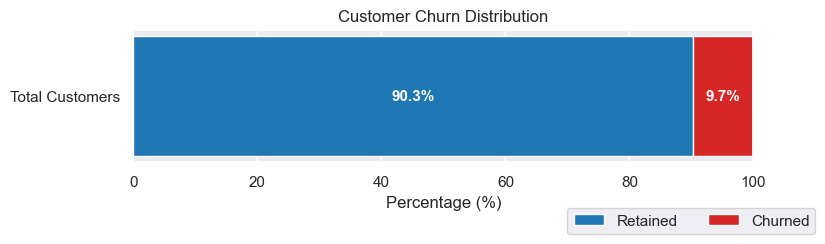

In [20]:
# Calculate churn percentages (ensure consistent order: 0 = Retained, 1 = Churned)
churn_pct = (
    client_df['churn'].value_counts(normalize=True)
    .reindex([0, 1], fill_value=0).mul(100)
)

# Plot a single horizontal stacked bar
fig, ax = plt.subplots(figsize=(8, 2.5))

left = 0
colors = ['#1f77b4', '#d62728']
labels = ['Retained', 'Churned']

for value, color, label in zip(churn_pct, colors, labels):
    ax.barh('Total Customers', value, left=left, color=color, label=label)

    # Add percentage label if segment is visible
    if value > 0:
        ax.text(left + value / 2, 0,
            f'{value:.1f}%',
            ha='center', va='center',
            color='white', fontsize=11,
            fontweight='bold'
        )

    left += value

# Formatting
ax.set_xlim(0, 100)
ax.set_xlabel('Percentage (%)')
ax.set_title('Customer Churn Distribution')
ax.legend(loc='lower center', bbox_to_anchor=(0.9, -0.6), ncol=2)

#plt.tight_layout()
fig.subplots_adjust(bottom=0.35)
plt.show()

> Approximately 10% of customers have churned.  
> From the visual above it is worthy to note that theres a high level of imbalance in the target class as the churned class only makeup about 10% of the dataset.

#### Features Distribution by Churn

In [21]:
"""
    Plot the distribution of a feature by churn.

    - Numerical features -> Strip plot
    - Categorical features -> Count plot
    """

def plot_feature_vs_churn(
    df,
    feature,
    target="churn",
    figsize=(7, 3),
    log_scale=True
):

    plt.figure(figsize=figsize)

    # ---------- Numerical Features ----------
    if pd.api.types.is_numeric_dtype(df[feature]) and df[feature].nunique() > 15:

        ax = sns.stripplot(
            data=df,
            x=feature,
            y=target,
            hue=target,
            orient="h",
            jitter=0.2,
            alpha=0.4,
            palette=["#1f77b4", "#ff7f0e"],
            legend=False
        )

        # Apply log scale only if appropriate
        if log_scale and (df[feature] > 0).all():
            ax.set_xscale("log")
            xlabel = f"{feature.replace('_', ' ').title()} (Log Scale)"
        else:
            xlabel = feature.replace("_", " ").title()

        ax.set_yticks([0, 1])
        ax.set_yticklabels(["Retained", "Churned"])

        plt.xlabel(xlabel)
        plt.ylabel("Customer Status")
        plt.title(f"{feature.replace('_', ' ').title()} by Customer Churn")

    # ---------- Categorical Features ----------
    else:

        ax = sns.countplot(
            data=df,
            x=feature,
            hue=target,
            palette=["#1f77b4", "#ff7f0e"]
        )

        plt.title(f"{feature.replace('_', ' ').title()} by Customer Churn")
        plt.xlabel(feature.replace("_", " ").title())
        plt.ylabel("Number of Customers")

        handles, _ = ax.get_legend_handles_labels()
        ax.legend(handles, ["Retained", "Churned"], title="Customer Status")

    plt.tight_layout()
    plt.show()

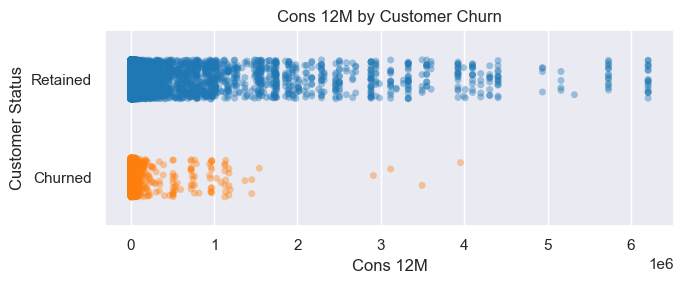

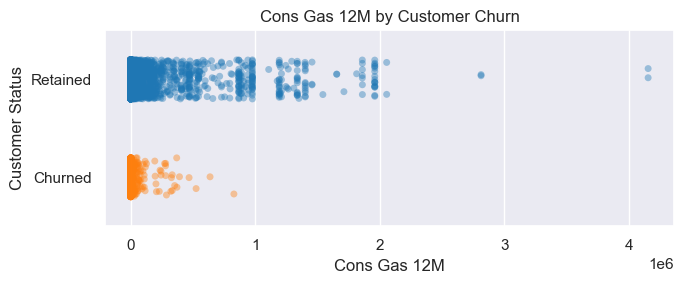

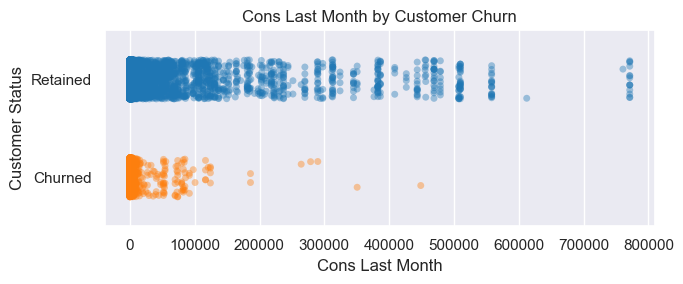

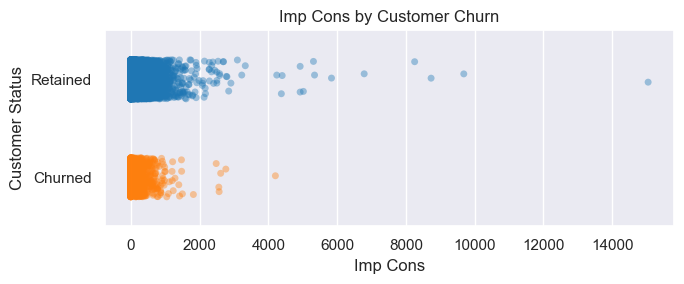

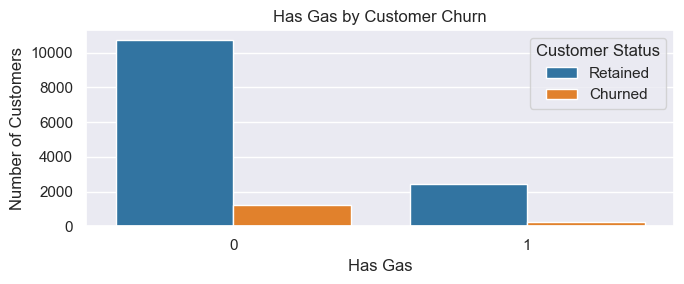

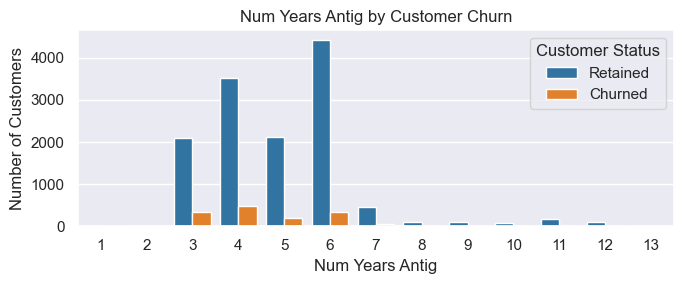

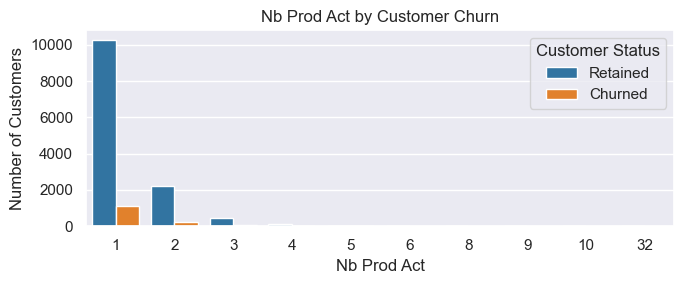

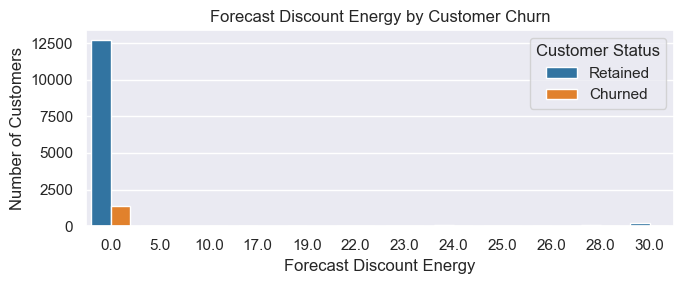

In [22]:
features = [
    "cons_12m",
    "cons_gas_12m",
    "cons_last_month",
    "imp_cons",
    'has_gas',
    'num_years_antig',
    'nb_prod_act',
    'forecast_discount_energy'
]

for feature in features:
    plot_feature_vs_churn(client_df, feature)                           

> The stripplot for most of the features reveals that our data is heavily right-skewed with extreme outliers.  
> Also, from the plot we can also deduce that most of the churned customers are small scale customers and that churn spreads across the distribution of each feature.

***Note:** To visualise the churn distribution for any of the other columns we can update the `features` variable in the cell block above.*

#### Channel Sales Comparison

In [23]:
channel_df = client_df[['channel_sales', 'churn', 'id']]

In [24]:
# Create summary table
channel_summary = channel_df.groupby(['channel_sales', 'churn'])['id'].count().unstack(level=1, fill_value=0)\
                .sort_values(by=1, ascending=False)
channel_summary

churn,0,1
channel_sales,,
foosdfpfkusacimwkcsosbicdxkicaua,5934,820
MISSING,3442,283
usilxuppasemubllopkaafesmlibmsdf,1237,138
lmkebamcaaclubfxadlmueccxoimlema,1740,103
ewpakwlliwisiwduibdlfmalxowmwpci,818,75
epumfxlbckeskwekxbiuasklxalciiuu,3,0
fixdbufsefwooaasfcxdxadsiekoceaa,2,0
sddiedcslfslkckwlfkdpoeeailfpeds,11,0


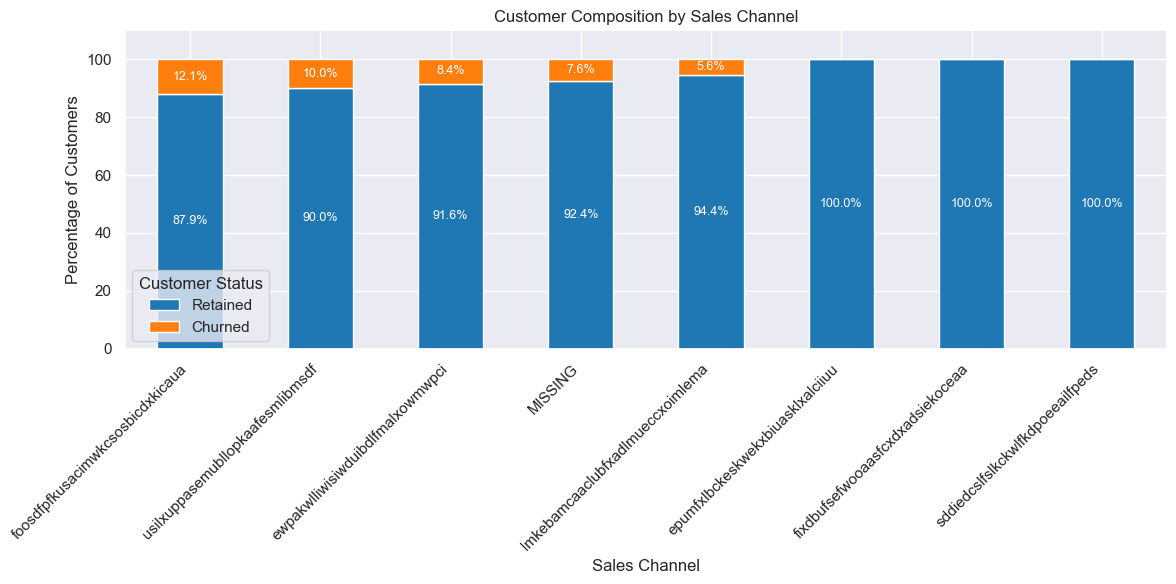

In [25]:

# Calculate percentages
channel_pct = channel_summary.div(channel_summary.sum(axis=1), axis=0) * 100
channel_pct = channel_pct.sort_values(by=1, ascending=False)

# Plot
fig, ax = plt.subplots(figsize=(12,6))

channel_pct.plot(kind='bar', stacked=True, color=['#1f77b4', '#ff7f0e'],
    ax=ax)

# Add percentage labels
for container in ax.containers:
    labels = [f'{v:.1f}%' if v > 4 else ''
        for v in container.datavalues]
    
    ax.bar_label(container, labels=labels,
        label_type='center',
        color='white', fontsize=9
    )

ax.set_ylim(0, 110)
ax.set_ylabel("Percentage of Customers")
ax.set_xlabel("Sales Channel")
ax.set_title("Customer Composition by Sales Channel")
ax.legend(["Retained", "Churned"], title="Customer Status")

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

---

## Feature Engineering





### client_df feature engineering

In [26]:
# checkpoint
client_dff = client_df.copy()
client_dff.columns

Index(['id', 'channel_sales', 'cons_12m', 'cons_gas_12m', 'cons_last_month',
       'date_activ', 'date_end', 'date_modif_prod', 'date_renewal',
       'forecast_cons_12m', 'forecast_cons_year', 'forecast_discount_energy',
       'forecast_meter_rent_12m', 'forecast_price_energy_off_peak',
       'forecast_price_energy_peak', 'forecast_price_pow_off_peak', 'has_gas',
       'imp_cons', 'margin_gross_pow_ele', 'margin_net_pow_ele', 'nb_prod_act',
       'net_margin', 'num_years_antig', 'origin_up', 'pow_max', 'churn'],
      dtype='str')

### Customer Tenure

How long has the customer been a client of PowerCo.

In [27]:
client_dff['tenure'] = ((client_dff['date_end'] - client_dff['date_activ']).dt.days// 365)

In [28]:
client_dff.groupby(['tenure']).agg({'churn': 'mean'}).sort_values(by='tenure', ascending=False)

,churn
tenure,
13,0.095238
12,0.083333
11,0.059783
10,0.045455
9,0.012500
8,0.047244
7,0.075472
6,0.075407
5,0.091999


We can see that companies who have only been a client for 4 or less months are much more likely to churn compared to companies that have been a client for longer. Interestingly, the difference between 4 and 5 months is about 4%, which represents a large jump in likelihood for a customer to churn compared to the other differences between ordered tenure values. Perhaps this reveals that getting a customer to over 4 months tenure is actually a large milestone with respect to keeping them as a long term customer. 

This is an interesting feature to keep for modelling because tenure is clearly correlated with churn probability.

### Transforming dates into months

- months_activ = Number of months active until reference date (Jan 2016)
- months_to_end = Number of months of the contract left until reference date (Jan 2016)
- months_modif_prod = Number of months since last modification until reference date (Jan 2016)
- months_renewal = Number of months since last renewal until reference date (Jan 2016)

Dates as a datetime object are not useful for a predictive model, so we needed to use the datetimes to create some other features that may hold some predictive power. 

Using intuition, one could assume that a client who has been an active client of PowerCo for a longer amount of time may have more loyalty to the brand and is more likely to stay, whereas a newer client may be more volatile. Hence the addition of the `months_activ` feature.

In addition, if customers are coming up to a contract end date, there may be a natural break point where it is cheaper or involves less friction to change. Therefore, `months_to_end` could be an interesting feature.

Alternatively, contract modification or renewal is a sign of engagement and may indicate clients are less likely to churn, so we can add two features to capture this: `months_modif_prod` and `months_renewal`.

In [29]:
def convert_months(reference_date, df, column):
    """
    return number of whole months between two dates
    """
    dates = pd.to_datetime(df[column])

    year_diff  = reference_date.year  - dates.dt.year
    month_diff = reference_date.month - dates.dt.month

    # initial month count
    months = year_diff * 12 + month_diff

    # subtract 1 if the reference day hasn't been reached yet in that month
    months -= (reference_date.day < dates.dt.day).astype(int)

    return months

In [30]:
# Create reference date
from datetime import datetime

reference_date = datetime(2016, 1, 1)

# Create columns
client_dff['months_activ'] = convert_months(reference_date, client_dff, 'date_activ')
client_dff['months_to_end'] = -convert_months(reference_date, client_dff, 'date_end') # calculates the time backwards (how far the end date is past the reference date)
client_dff['months_modif_prod'] = convert_months(reference_date, client_dff, 'date_modif_prod')
client_dff['months_renewal'] = convert_months(reference_date, client_dff, 'date_renewal')

In [31]:
# We no longer need the datetime columns that we used for feature engineering, so we can drop them
remove = [
    'date_activ',
    'date_end',
    'date_modif_prod',
    'date_renewal'
]

client_dff = client_dff.drop(columns=remove)
client_dff.head()

,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,forecast_cons_12m,forecast_cons_year,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,...,net_margin,num_years_antig,origin_up,pow_max,churn,tenure,months_activ,months_to_end,months_modif_prod,months_renewal
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,0.00,0,0.0,1.78,0.114481,...,678.99,3,lxidpiddsbxsbosboudacockeimpuepw,43.648,1,3,30,6,2,6
1,d29c2c54acc38ff3c0614d0a653813dd,MISSING,4660,0,0,189.95,0,0.0,16.27,0.145711,...,18.89,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.800,0,7,76,8,76,4
2,764c75f661154dac3a6c254cd082ea7d,foosdfpfkusacimwkcsosbicdxkicaua,544,0,0,47.96,0,0.0,38.72,0.165794,...,6.60,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.856,0,6,68,4,68,8
3,bba03439a292a1e166f80264c16191cb,lmkebamcaaclubfxadlmueccxoimlema,1584,0,0,240.04,0,0.0,19.83,0.146694,...,25.46,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.200,0,6,69,3,69,9
4,149d57cf92fc41cf94415803a877cb4b,MISSING,4425,0,526,445.75,526,0.0,131.73,0.116900,...,47.98,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,19.800,0,6,71,3,71,9


### Transforming categorical data

A predictive model cannot accept categorical or `string` values, so these variables need to be transformed before they can be used in modeling. One method is to map each category to an integer (label encoding), however this is not always appropriate because it then introduces the concept of an order into a feature which may not inherently be present `0 < 1 < 2 < 3 ...`

Another way to encode categorical features is to use `dummy variables`  (also know as `one hot encoding`). This creates a new feature for every unique value of a categorical column, and fills this column with either a 1 or a 0 to indicate that this company does or does not belong to this category. Since it isn't useful to add features to our model where there are 0's for most rows, we will drop any category that shows up less than 100 times in our dataset.

The Categorical columns in this dataset includes `'channel_sales', 'has_gas', 'origin_up'`,   
However `'has_gas'` is already encoded as there is only one category - i.e. if a Customer has gas facility`"1"` or not then `"0"`- therefore we shall exclude `'has_gas'` from the categorical columns to be encoded.



#### channel_sales and origin_up

In [32]:
cols = ['channel_sales', 'origin_up']
min_count = 100

# get counts per category so we can filter out rare categories
value_counts = {col: client_dff[col].value_counts() for col in cols}

client_dff = pd.get_dummies(client_dff, columns=cols, prefix=cols, dtype=int)

# drop rare columns
for col in cols:
    keep_cols = set(value_counts[col][value_counts[col] >= min_count].index.astype(str))

    dummy_cols = [c for c in client_dff.columns if c.startswith(f"{col}_")]
    drop_cols = [c for c in dummy_cols if c.split(f"{col}_", 1)[1] not in keep_cols]
    client_dff.drop(columns=drop_cols, inplace=True)



### Transforming numerical data

In the previous exercise we saw that some variables were highly skewed. The reason why we need to treat skewness is because some predictive models have inherent assumptions about the distribution of the features. Such models are called `parametric` models, and they typically assume that all variables are both independent and normally distributed.

Skewness isn't always a bad thing, but as a rule of thumb it is good practice to treat highly skewed variables to make them more normally distributed. This can also increase the speed at which predictive models are able to converge to the best solution.

There are many ways that you can treat skewed variables. You can apply transformations such as:
- Square root
- Cubic root
- Logarithm

 For this use case we will use the 'Logarithm' transformation for the positively skewed features. 

**Note:** We cannot apply log to a value of 0, so we will add a constant of 1 to all the values

We will check the distributions before and after transformation, and expect the standard deviations to decrease.

In [33]:
skewed_cols = [
    'cons_12m', 
    'cons_gas_12m', 
    'cons_last_month',
    'forecast_cons_12m', 
    'forecast_cons_year', 
    'forecast_discount_energy',
    'forecast_meter_rent_12m', 
    'forecast_price_energy_off_peak',
    'forecast_price_energy_peak', 
    'forecast_price_pow_off_peak'
]

print("Before log transform:")
print(client_dff[skewed_cols].describe())

client_dff[skewed_cols] = np.log10(client_dff[skewed_cols] + 1)

print("After log transform:")
print(client_dff[skewed_cols].describe())

Before log transform:
           cons_12m  cons_gas_12m  cons_last_month  forecast_cons_12m  \
count  1.460600e+04  1.460600e+04     14606.000000       14606.000000   
mean   1.592203e+05  2.809238e+04     16090.269752        1868.614880   
std    5.734653e+05  1.629731e+05     64364.196422        2387.571531   
min    0.000000e+00  0.000000e+00         0.000000           0.000000   
25%    5.674750e+03  0.000000e+00         0.000000         494.995000   
50%    1.411550e+04  0.000000e+00       792.500000        1112.875000   
75%    4.076375e+04  0.000000e+00      3383.000000        2401.790000   
max    6.207104e+06  4.154590e+06    771203.000000       82902.830000   

       forecast_cons_year  forecast_discount_energy  forecast_meter_rent_12m  \
count        14606.000000              14606.000000             14606.000000   
mean          1399.762906                  0.966726                63.086871   
std           3247.786255                  5.108289                66.165783   


Now we can see that for the majority of the features, the standard deviation is much lower after transformation. This is a good thing as it shows that these features are more stable and predictable now.

Let's plot a few of these distributions too.

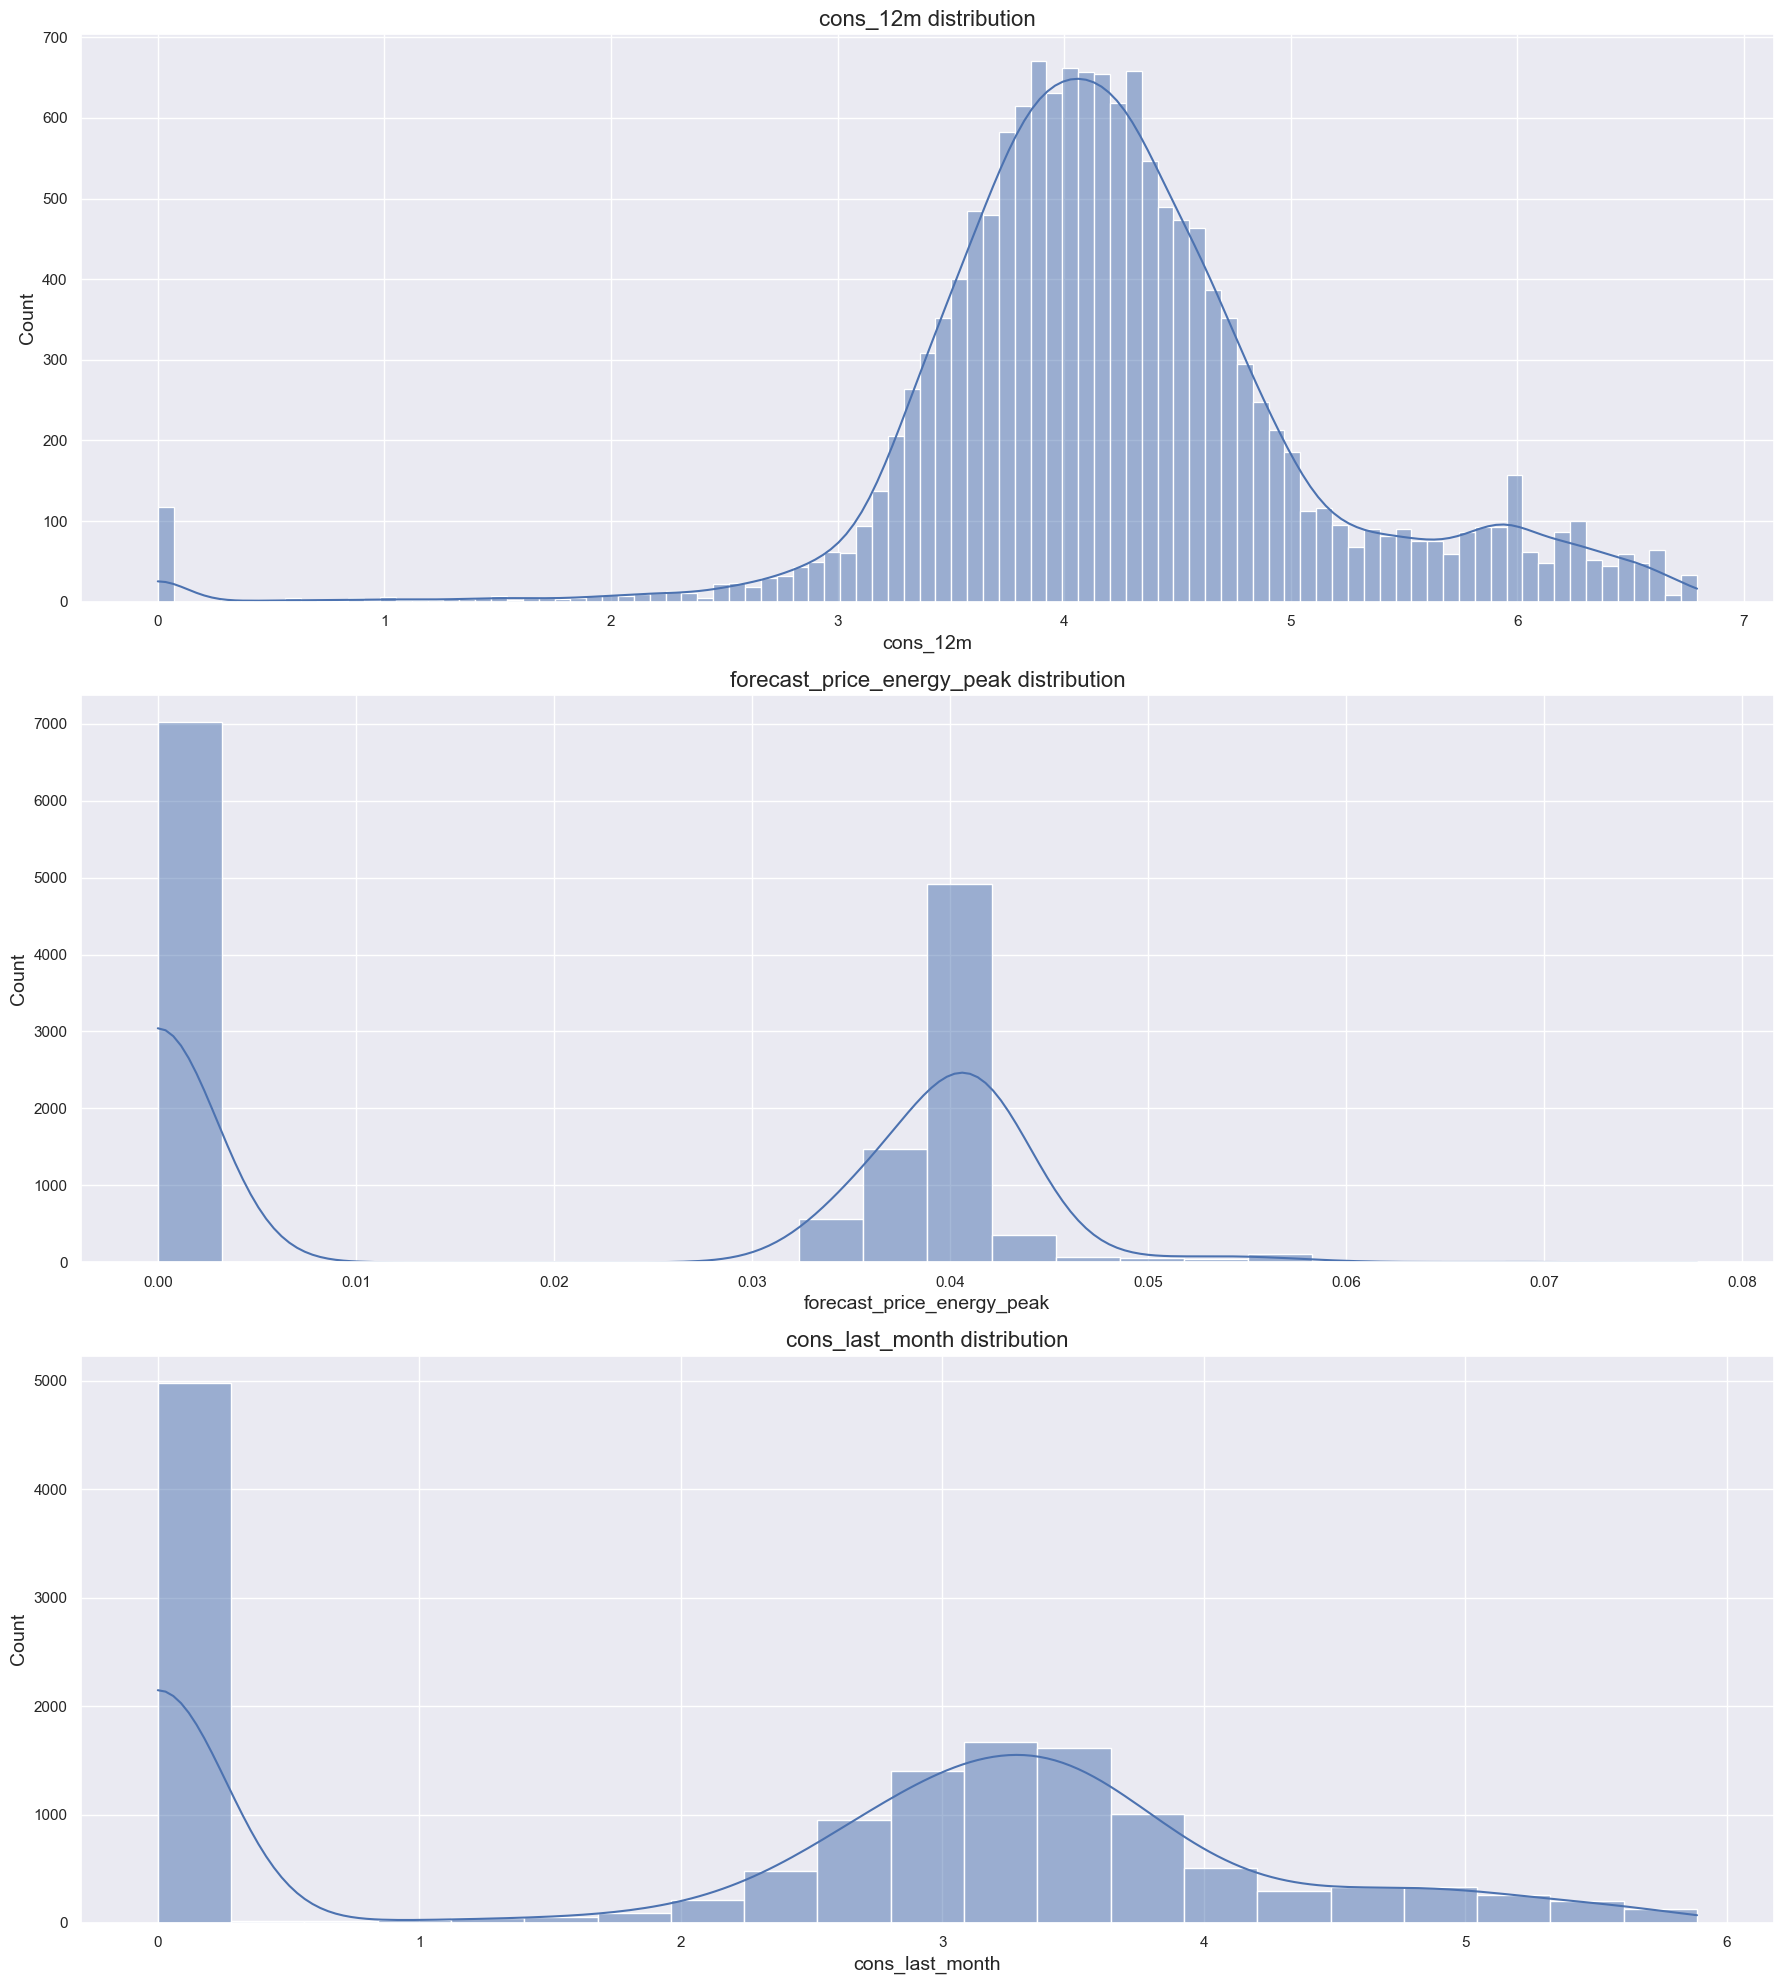

In [34]:
cols = ["cons_12m", "forecast_price_energy_peak", "cons_last_month"]

# Set up subplots
fig, axs = plt.subplots(nrows=len(cols), figsize=(18, 20))

# Loop through each column and plot
for ax, col in zip(axs, cols):
    sns.histplot(client_dff[col].dropna(), kde=True, ax=ax)
    ax.set_title(f"{col} distribution", fontsize=16)
    ax.set_xlabel(col, fontsize=14)
    ax.set_ylabel("Count", fontsize=14)

plt.tight_layout()
plt.show()

In [35]:
client_dff.head()

,id,cons_12m,cons_gas_12m,cons_last_month,forecast_cons_12m,forecast_cons_year,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,...,months_modif_prod,months_renewal,channel_sales_MISSING,channel_sales_ewpakwlliwisiwduibdlfmalxowmwpci,channel_sales_foosdfpfkusacimwkcsosbicdxkicaua,channel_sales_lmkebamcaaclubfxadlmueccxoimlema,channel_sales_usilxuppasemubllopkaafesmlibmsdf,origin_up_kamkkxfxxuwbdslkwifmmcsiusiuosws,origin_up_ldkssxwpmemidmecebumciepifcamkci,origin_up_lxidpiddsbxsbosboudacockeimpuepw
0,24011ae4ebbe3035111d65fa7c15bc57,0.000000,4.739944,0.000000,0.000000,0.000000,0.0,0.444045,0.047073,0.040659,...,2,6,0,0,1,0,0,0,0,1
1,d29c2c54acc38ff3c0614d0a653813dd,3.668479,0.000000,0.000000,2.280920,0.000000,0.0,1.237292,0.059075,0.000000,...,76,4,1,0,0,0,0,1,0,0
2,764c75f661154dac3a6c254cd082ea7d,2.736397,0.000000,0.000000,1.689841,0.000000,0.0,1.599009,0.066622,0.036589,...,68,8,0,0,1,0,0,1,0,0
3,bba03439a292a1e166f80264c16191cb,3.200029,0.000000,0.000000,2.382089,0.000000,0.0,1.318689,0.059448,0.000000,...,69,9,0,0,0,1,0,1,0,0
4,149d57cf92fc41cf94415803a877cb4b,3.646011,0.000000,2.721811,2.650065,2.721811,0.0,2.122969,0.048014,0.041399,...,71,9,1,0,0,0,0,1,0,0


---
### price_df feature engineering

The `price_df` contains multiple historical price records for each customer, while `client_df` contains one record per customer.

The primary goal of this feature engineering is to summarize each customer's price history into a single record so it can be merged with `client_df`.


Therefore we need to transform the time-series table *(many records per customer)* into summarized versions *(one record per customer)*. We will create features that capture price levels, differences between periods, and changes in prices over time. These features provide a better representation of each customer's pricing experience and can help investigate whether price changes are associated with customer churn.


In [36]:
price_dff= price_df.copy()
price_dff.head()

,id,price_date,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
0,038af19179925da21a25619c5a24b745,2015-01-01,0.151367,0.0,0.0,44.266931,0.0,0.0
1,038af19179925da21a25619c5a24b745,2015-02-01,0.151367,0.0,0.0,44.266931,0.0,0.0
2,038af19179925da21a25619c5a24b745,2015-03-01,0.151367,0.0,0.0,44.266931,0.0,0.0
3,038af19179925da21a25619c5a24b745,2015-04-01,0.149626,0.0,0.0,44.266931,0.0,0.0
4,038af19179925da21a25619c5a24b745,2015-05-01,0.149626,0.0,0.0,44.266931,0.0,0.0


 Lets examine the varying total number of records per customer. If we get only 12 as the result, then we can assume the dataset has a perfect 12 months record per client.

In [37]:
# Varying no. of records per id
price_dff.groupby('id').size().unique()


array([12, 11, 10,  7,  8,  9])

In [38]:
# sort price dates per id
price_dff["price_date"] = pd.to_datetime(price_dff["price_date"])

price_dff = price_dff.sort_values(["id", "price_date"])

#### Create a New price_df 

We need to convert the multiple records per customer into one price record per customer.


In [39]:
# Create a new price_df with unique id's
new_price_df = price_dff.copy().groupby('id').mean().drop(columns ='price_date')

new_price_df.head()

,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
id,,,,,,
0002203ffbb812588b632b9e628cc38d,0.124338,0.103794,0.073160,40.701732,24.421038,16.280694
0004351ebdd665e6ee664792efc4fd13,0.146426,0.000000,0.000000,44.385450,0.000000,0.000000
0010bcc39e42b3c2131ed2ce55246e3c,0.181558,0.000000,0.000000,45.319710,0.000000,0.000000
0010ee3855fdea87602a5b7aba8e42de,0.118757,0.098292,0.069032,40.647427,24.388455,16.258971
00114d74e963e47177db89bc70108537,0.147926,0.000000,0.000000,44.266930,0.000000,0.000000


> Now we can subsequently merge engineered features to this `new_price_df`



#### Inter Period price Sensitivity

Determine periodical price changes across periods for Analysing price Sensivity

In [40]:
# AThen we ggregate the averages of the different prices for each customer 
mean_prices = price_dff.groupby(['id']).agg({
    'price_off_peak_var': 'mean', 
    'price_peak_var': 'mean', 
    'price_mid_peak_var': 'mean',
    'price_off_peak_fix': 'mean',
    'price_peak_fix': 'mean',
    'price_mid_peak_fix': 'mean', 
}).reset_index()

mean_prices.head()

,id,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
0,0002203ffbb812588b632b9e628cc38d,0.124338,0.103794,0.073160,40.701732,24.421038,16.280694
1,0004351ebdd665e6ee664792efc4fd13,0.146426,0.000000,0.000000,44.385450,0.000000,0.000000
2,0010bcc39e42b3c2131ed2ce55246e3c,0.181558,0.000000,0.000000,45.319710,0.000000,0.000000
3,0010ee3855fdea87602a5b7aba8e42de,0.118757,0.098292,0.069032,40.647427,24.388455,16.258971
4,00114d74e963e47177db89bc70108537,0.147926,0.000000,0.000000,44.266930,0.000000,0.000000


In [41]:
# Calculate the mean difference between consecutive periods
mean_prices['off_peak_peak_var_mean_diff'] = mean_prices['price_off_peak_var'] - mean_prices['price_peak_var']
mean_prices['off_peak_peak_fix_mean_diff'] = mean_prices['price_off_peak_fix'] - mean_prices['price_peak_fix']
mean_prices['peak_mid_peak_var_mean_diff'] = mean_prices['price_peak_var'] - mean_prices['price_mid_peak_var']
mean_prices['peak_mid_peak_fix_mean_diff'] = mean_prices['price_peak_fix'] - mean_prices['price_mid_peak_fix']
mean_prices['off_peak_mid_peak_var_mean_diff'] = mean_prices['price_off_peak_var'] - mean_prices['price_mid_peak_var']
mean_prices['off_peak_mid_peak_fix_mean_diff'] = mean_prices['price_off_peak_fix'] - mean_prices['price_mid_peak_fix']

In [42]:
columns = [
    'id', 
    'off_peak_peak_var_mean_diff',
    'peak_mid_peak_var_mean_diff', 
    'off_peak_mid_peak_var_mean_diff',
    'off_peak_peak_fix_mean_diff', 
    'peak_mid_peak_fix_mean_diff', 
    'off_peak_mid_peak_fix_mean_diff'
]
new_price_df = pd.merge(new_price_df, mean_prices[columns], on='id')
new_price_df.head()

,id,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix,off_peak_peak_var_mean_diff,peak_mid_peak_var_mean_diff,off_peak_mid_peak_var_mean_diff,off_peak_peak_fix_mean_diff,peak_mid_peak_fix_mean_diff,off_peak_mid_peak_fix_mean_diff
0,0002203ffbb812588b632b9e628cc38d,0.124338,0.103794,0.073160,40.701732,24.421038,16.280694,0.020545,0.030633,0.051178,16.280694,8.140345,24.421038
1,0004351ebdd665e6ee664792efc4fd13,0.146426,0.000000,0.000000,44.385450,0.000000,0.000000,0.146426,0.000000,0.146426,44.385450,0.000000,44.385450
2,0010bcc39e42b3c2131ed2ce55246e3c,0.181558,0.000000,0.000000,45.319710,0.000000,0.000000,0.181558,0.000000,0.181558,45.319710,0.000000,45.319710
3,0010ee3855fdea87602a5b7aba8e42de,0.118757,0.098292,0.069032,40.647427,24.388455,16.258971,0.020465,0.029260,0.049725,16.258972,8.129484,24.388456
4,00114d74e963e47177db89bc70108537,0.147926,0.000000,0.000000,44.266930,0.000000,0.000000,0.147926,0.000000,0.147926,44.266930,0.000000,44.266930


####  Price variation Sensitivity over a specified number of months

We compute the one year difference in price

In [43]:
# Aggregate price_df to one record per customer for each month 

agg_dict = {
    col: "mean"
    for col in price_dff.columns
    if col not in ["id", "price_date"]
}

monthly_price = (
    price_dff
    .groupby(["id", "price_date"])
    .agg(agg_dict)
    .reset_index()
)

monthly_price.head()

,id,price_date,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
0,0002203ffbb812588b632b9e628cc38d,2015-01-01,0.126098,0.103975,0.070232,40.565969,24.339581,16.226389
1,0002203ffbb812588b632b9e628cc38d,2015-02-01,0.126098,0.103975,0.070232,40.565969,24.339581,16.226389
2,0002203ffbb812588b632b9e628cc38d,2015-03-01,0.128067,0.105842,0.073773,40.728885,24.437330,16.291555
3,0002203ffbb812588b632b9e628cc38d,2015-04-01,0.128067,0.105842,0.073773,40.728885,24.437330,16.291555
4,0002203ffbb812588b632b9e628cc38d,2015-05-01,0.128067,0.105842,0.073773,40.728885,24.437330,16.291555


In [44]:
# Function to compare price differences across specific number of months.
def price_variation(group, duration):

    group = group.sort_values("price_date")

    # Latest available record
    latest = group.iloc[-1]

    # Specify the target duration 'months' before the latest record
    target_date = latest["price_date"] - pd.DateOffset(months=duration)

    # Find the closest record on or before the target date
    previous_rows = group[group["price_date"] <= target_date]

    if previous_rows.empty:
        previous = group.iloc[0]
    else:
        previous = previous_rows.iloc[-1]

    result = {}

    # Filter all price-related columns
    price_cols = [
        col for col in group.columns
        if col not in ["id", "price_date"]
    ]

    for col in price_cols:
        result[f"var_{duration}m_{col}"] = latest[col] - previous[col]

    return pd.Series(result)

In [45]:
# Call the "price_variation" to compute 12months price difference
var_12m = (
    monthly_price
    .groupby("id")
    .apply(price_variation, duration=12)
    .reset_index()
)
var_12m.head()

,id,var_12m_price_off_peak_var,var_12m_price_peak_var,var_12m_price_mid_peak_var,var_12m_price_off_peak_fix,var_12m_price_peak_fix,var_12m_price_mid_peak_fix
0,0002203ffbb812588b632b9e628cc38d,-0.006192,-0.002302,0.003487,0.162916,0.097749,0.065166
1,0004351ebdd665e6ee664792efc4fd13,-0.004104,0.000000,0.000000,0.177779,0.000000,0.000000
2,0010bcc39e42b3c2131ed2ce55246e3c,0.050443,0.000000,0.000000,1.500000,0.000000,0.000000
3,0010ee3855fdea87602a5b7aba8e42de,-0.010018,-0.005120,0.000763,0.162916,0.097749,0.065166
4,00114d74e963e47177db89bc70108537,-0.003994,0.000000,0.000000,-0.000001,0.000000,0.000000


In [46]:
new_price_df = pd.merge(new_price_df, var_12m, on='id')
new_price_df.head()

,id,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix,off_peak_peak_var_mean_diff,peak_mid_peak_var_mean_diff,off_peak_mid_peak_var_mean_diff,off_peak_peak_fix_mean_diff,peak_mid_peak_fix_mean_diff,off_peak_mid_peak_fix_mean_diff,var_12m_price_off_peak_var,var_12m_price_peak_var,var_12m_price_mid_peak_var,var_12m_price_off_peak_fix,var_12m_price_peak_fix,var_12m_price_mid_peak_fix
0,0002203ffbb812588b632b9e628cc38d,0.124338,0.103794,0.073160,40.701732,24.421038,16.280694,0.020545,0.030633,0.051178,16.280694,8.140345,24.421038,-0.006192,-0.002302,0.003487,0.162916,0.097749,0.065166
1,0004351ebdd665e6ee664792efc4fd13,0.146426,0.000000,0.000000,44.385450,0.000000,0.000000,0.146426,0.000000,0.146426,44.385450,0.000000,44.385450,-0.004104,0.000000,0.000000,0.177779,0.000000,0.000000
2,0010bcc39e42b3c2131ed2ce55246e3c,0.181558,0.000000,0.000000,45.319710,0.000000,0.000000,0.181558,0.000000,0.181558,45.319710,0.000000,45.319710,0.050443,0.000000,0.000000,1.500000,0.000000,0.000000
3,0010ee3855fdea87602a5b7aba8e42de,0.118757,0.098292,0.069032,40.647427,24.388455,16.258971,0.020465,0.029260,0.049725,16.258972,8.129484,24.388456,-0.010018,-0.005120,0.000763,0.162916,0.097749,0.065166
4,00114d74e963e47177db89bc70108537,0.147926,0.000000,0.000000,44.266930,0.000000,0.000000,0.147926,0.000000,0.147926,44.266930,0.000000,44.266930,-0.003994,0.000000,0.000000,-0.000001,0.000000,0.000000


### Max price changes across periods and months

Another way we can enhance the features is to look at the maximum change in prices across consecutive periods through out the customers tenure *(i.e., recorded months of partronage)* this is because customers might be more likely to churn if they experience sudden large price changes.

In [47]:
# Aggregate average prices per period by company
mean_prices_by_month = price_dff.groupby(['id', 'price_date']).agg({
    'price_off_peak_var': 'mean', 
    'price_peak_var': 'mean', 
    'price_mid_peak_var': 'mean',
    'price_off_peak_fix': 'mean',
    'price_peak_fix': 'mean',
    'price_mid_peak_fix': 'mean'    
}).reset_index()

In [48]:
# Calculate the mean difference between consecutive periods
mean_prices_by_month['off_peak_peak_var_mean_diff'] = mean_prices_by_month['price_off_peak_var'] - mean_prices_by_month['price_peak_var']
mean_prices_by_month['off_peak_peak_fix_mean_diff'] = mean_prices_by_month['price_off_peak_fix'] - mean_prices_by_month['price_peak_fix']
mean_prices_by_month['peak_mid_peak_var_mean_diff'] = mean_prices_by_month['price_peak_var'] - mean_prices_by_month['price_mid_peak_var']
mean_prices_by_month['peak_mid_peak_fix_mean_diff'] = mean_prices_by_month['price_peak_fix'] - mean_prices_by_month['price_mid_peak_fix']
mean_prices_by_month['off_peak_mid_peak_var_mean_diff'] = mean_prices_by_month['price_off_peak_var'] - mean_prices_by_month['price_mid_peak_var']
mean_prices_by_month['off_peak_mid_peak_fix_mean_diff'] = mean_prices_by_month['price_off_peak_fix'] - mean_prices_by_month['price_mid_peak_fix']

In [49]:
# Calculate the maximum monthly difference across time periods
max_diff_across_periods_months = mean_prices_by_month.groupby(['id']).agg({
    'off_peak_peak_var_mean_diff': 'max',
    'peak_mid_peak_var_mean_diff': 'max',
    'off_peak_mid_peak_var_mean_diff': 'max',
    'off_peak_peak_fix_mean_diff': 'max',
    'peak_mid_peak_fix_mean_diff': 'max',
    'off_peak_mid_peak_fix_mean_diff': 'max'
}).reset_index().rename(
    columns={
        'off_peak_peak_var_mean_diff': 'off_peak_peak_var_max_monthly_diff',
        'peak_mid_peak_var_mean_diff': 'peak_mid_peak_var_max_monthly_diff',
        'off_peak_mid_peak_var_mean_diff': 'off_peak_mid_peak_var_max_monthly_diff',
        'off_peak_peak_fix_mean_diff': 'off_peak_peak_fix_max_monthly_diff',
        'peak_mid_peak_fix_mean_diff': 'peak_mid_peak_fix_max_monthly_diff',
        'off_peak_mid_peak_fix_mean_diff': 'off_peak_mid_peak_fix_max_monthly_diff'
    }
)

In [50]:
columns = [
    'id',
    'off_peak_peak_var_max_monthly_diff',
    'peak_mid_peak_var_max_monthly_diff',
    'off_peak_mid_peak_var_max_monthly_diff',
    'off_peak_peak_fix_max_monthly_diff',
    'peak_mid_peak_fix_max_monthly_diff',
    'off_peak_mid_peak_fix_max_monthly_diff'
]

new_price_df = pd.merge(new_price_df, max_diff_across_periods_months[columns], on='id')
new_price_df.head()

,id,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix,off_peak_peak_var_mean_diff,peak_mid_peak_var_mean_diff,off_peak_mid_peak_var_mean_diff,...,var_12m_price_mid_peak_var,var_12m_price_off_peak_fix,var_12m_price_peak_fix,var_12m_price_mid_peak_fix,off_peak_peak_var_max_monthly_diff,peak_mid_peak_var_max_monthly_diff,off_peak_mid_peak_var_max_monthly_diff,off_peak_peak_fix_max_monthly_diff,peak_mid_peak_fix_max_monthly_diff,off_peak_mid_peak_fix_max_monthly_diff
0,0002203ffbb812588b632b9e628cc38d,0.124338,0.103794,0.073160,40.701732,24.421038,16.280694,0.020545,0.030633,0.051178,...,0.003487,0.162916,0.097749,0.065166,0.022225,0.033743,0.055866,16.291555,8.145775,24.437330
1,0004351ebdd665e6ee664792efc4fd13,0.146426,0.000000,0.000000,44.385450,0.000000,0.000000,0.146426,0.000000,0.146426,...,0.000000,0.177779,0.000000,0.000000,0.148405,0.000000,0.148405,44.444710,0.000000,44.444710
2,0010bcc39e42b3c2131ed2ce55246e3c,0.181558,0.000000,0.000000,45.319710,0.000000,0.000000,0.181558,0.000000,0.181558,...,0.000000,1.500000,0.000000,0.000000,0.205742,0.000000,0.205742,45.944710,0.000000,45.944710
3,0010ee3855fdea87602a5b7aba8e42de,0.118757,0.098292,0.069032,40.647427,24.388455,16.258971,0.020465,0.029260,0.049725,...,0.000763,0.162916,0.097749,0.065166,0.022581,0.031859,0.054440,16.291555,8.145775,24.437330
4,00114d74e963e47177db89bc70108537,0.147926,0.000000,0.000000,44.266930,0.000000,0.000000,0.147926,0.000000,0.147926,...,0.000000,-0.000001,0.000000,0.000000,0.149902,0.000000,0.149902,44.266931,0.000000,44.266931


---
### Merge the two New datasets

In [51]:
display(client_dff.shape)
display(new_price_df.shape)

(14606, 33)

(16096, 25)


It is observed that the `price_df` has more customer records than  `client_df`, we have to confirm that there are not duplicates.

In [52]:
display(new_price_df['id'].nunique())
display(new_price_df["id"].duplicated().sum())

# How many extra records does price_df have
missing_ids = new_price_df[~new_price_df['id'].isin(client_dff['id'])] # ['id'].unique()

# Print the missing IDs
print(f"There are {len(missing_ids)} IDs in pricedf that are missing from client_df.")
missing_ids.head()

16096

np.int64(0)

There are 1490 IDs in pricedf that are missing from client_df.


,id,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix,off_peak_peak_var_mean_diff,peak_mid_peak_var_mean_diff,off_peak_mid_peak_var_mean_diff,...,var_12m_price_mid_peak_var,var_12m_price_off_peak_fix,var_12m_price_peak_fix,var_12m_price_mid_peak_fix,off_peak_peak_var_max_monthly_diff,peak_mid_peak_var_max_monthly_diff,off_peak_mid_peak_var_max_monthly_diff,off_peak_peak_fix_max_monthly_diff,peak_mid_peak_fix_max_monthly_diff,off_peak_mid_peak_fix_max_monthly_diff
3,0010ee3855fdea87602a5b7aba8e42de,0.118757,0.098292,0.069032,40.647427,24.388455,16.258971,0.020465,0.029260,0.049725,...,0.000763,0.162916,0.097749,0.065166,0.022581,0.031859,0.054440,16.291555,8.145775,24.437330
5,00126c87cf78d7604278f0a9adeb689e,0.119806,0.099417,0.070304,40.661003,24.396601,16.264402,0.020389,0.029113,0.049502,...,-0.002127,0.162916,0.097749,0.065166,0.022581,0.031859,0.054440,16.291555,8.145775,24.437330
20,003e7fcd19e10f5114c29ce4a6997ba0,0.157671,0.000000,0.000000,44.883450,0.000000,0.000000,0.157671,0.000000,0.157671,...,0.000000,-1.316221,0.000000,0.000000,0.190481,0.000000,0.190481,45.760931,0.000000,45.760931
35,0066e1989bb69201a52a109ff68cb700,0.121060,0.100728,0.070521,40.579547,24.347725,16.231816,0.020332,0.030208,0.050539,...,-0.000686,0.162916,0.097749,0.065166,0.022136,0.031943,0.054079,16.291555,8.145775,24.437330
42,00741d1795e23f627bb7e8246c410cb3,0.199812,0.000000,0.000000,44.266930,0.000000,0.000000,0.199812,0.000000,0.199812,...,0.000000,-0.000001,0.000000,0.000000,0.201671,0.000000,0.201671,44.266931,0.000000,44.266931


This means the price dataset contains pricing records for some customers who do not have a corresponding record in the client dataset.

Since our target variable churn exists in client_df, those 1,490 customers have no predictive value to our churn model.

Therefore we shall treat client_df as our master dataset, that is we keep only those customers in client_df, and attach their price information where available.

> This is an important discovery as it determines the kind of merging we use for `client_df`

In [53]:
 # Merge client_df to new_price_df
engineered_df = client_dff.merge(
  new_price_df,
    on="id",
    how="left"
)
print('client_df and modified price_df has been merged')
print(engineered_df.shape)

# Save the new Engineered dataframe
engineered_df.to_csv(data_path/'engineered_df', index = False)

print('Engineered Data has been saved to PowerCo. churn/data/engineered_df.csv')


client_df and modified price_df has been merged
(14606, 57)
Engineered Data has been saved to PowerCo. churn/data/engineered_df.csv


---
### Feature Correlations

Creating new featuers requires trial and error and requires iteration. To determine if we are on the right track, we can check the correlation between our new features with our target variable of interest. We also want to check if features are highly correlated with each other (and leave only one in the model), since predictive models work best when the features are uncorrelated.

In [54]:
correlation = engineered_df.drop(columns=['id']).corr()

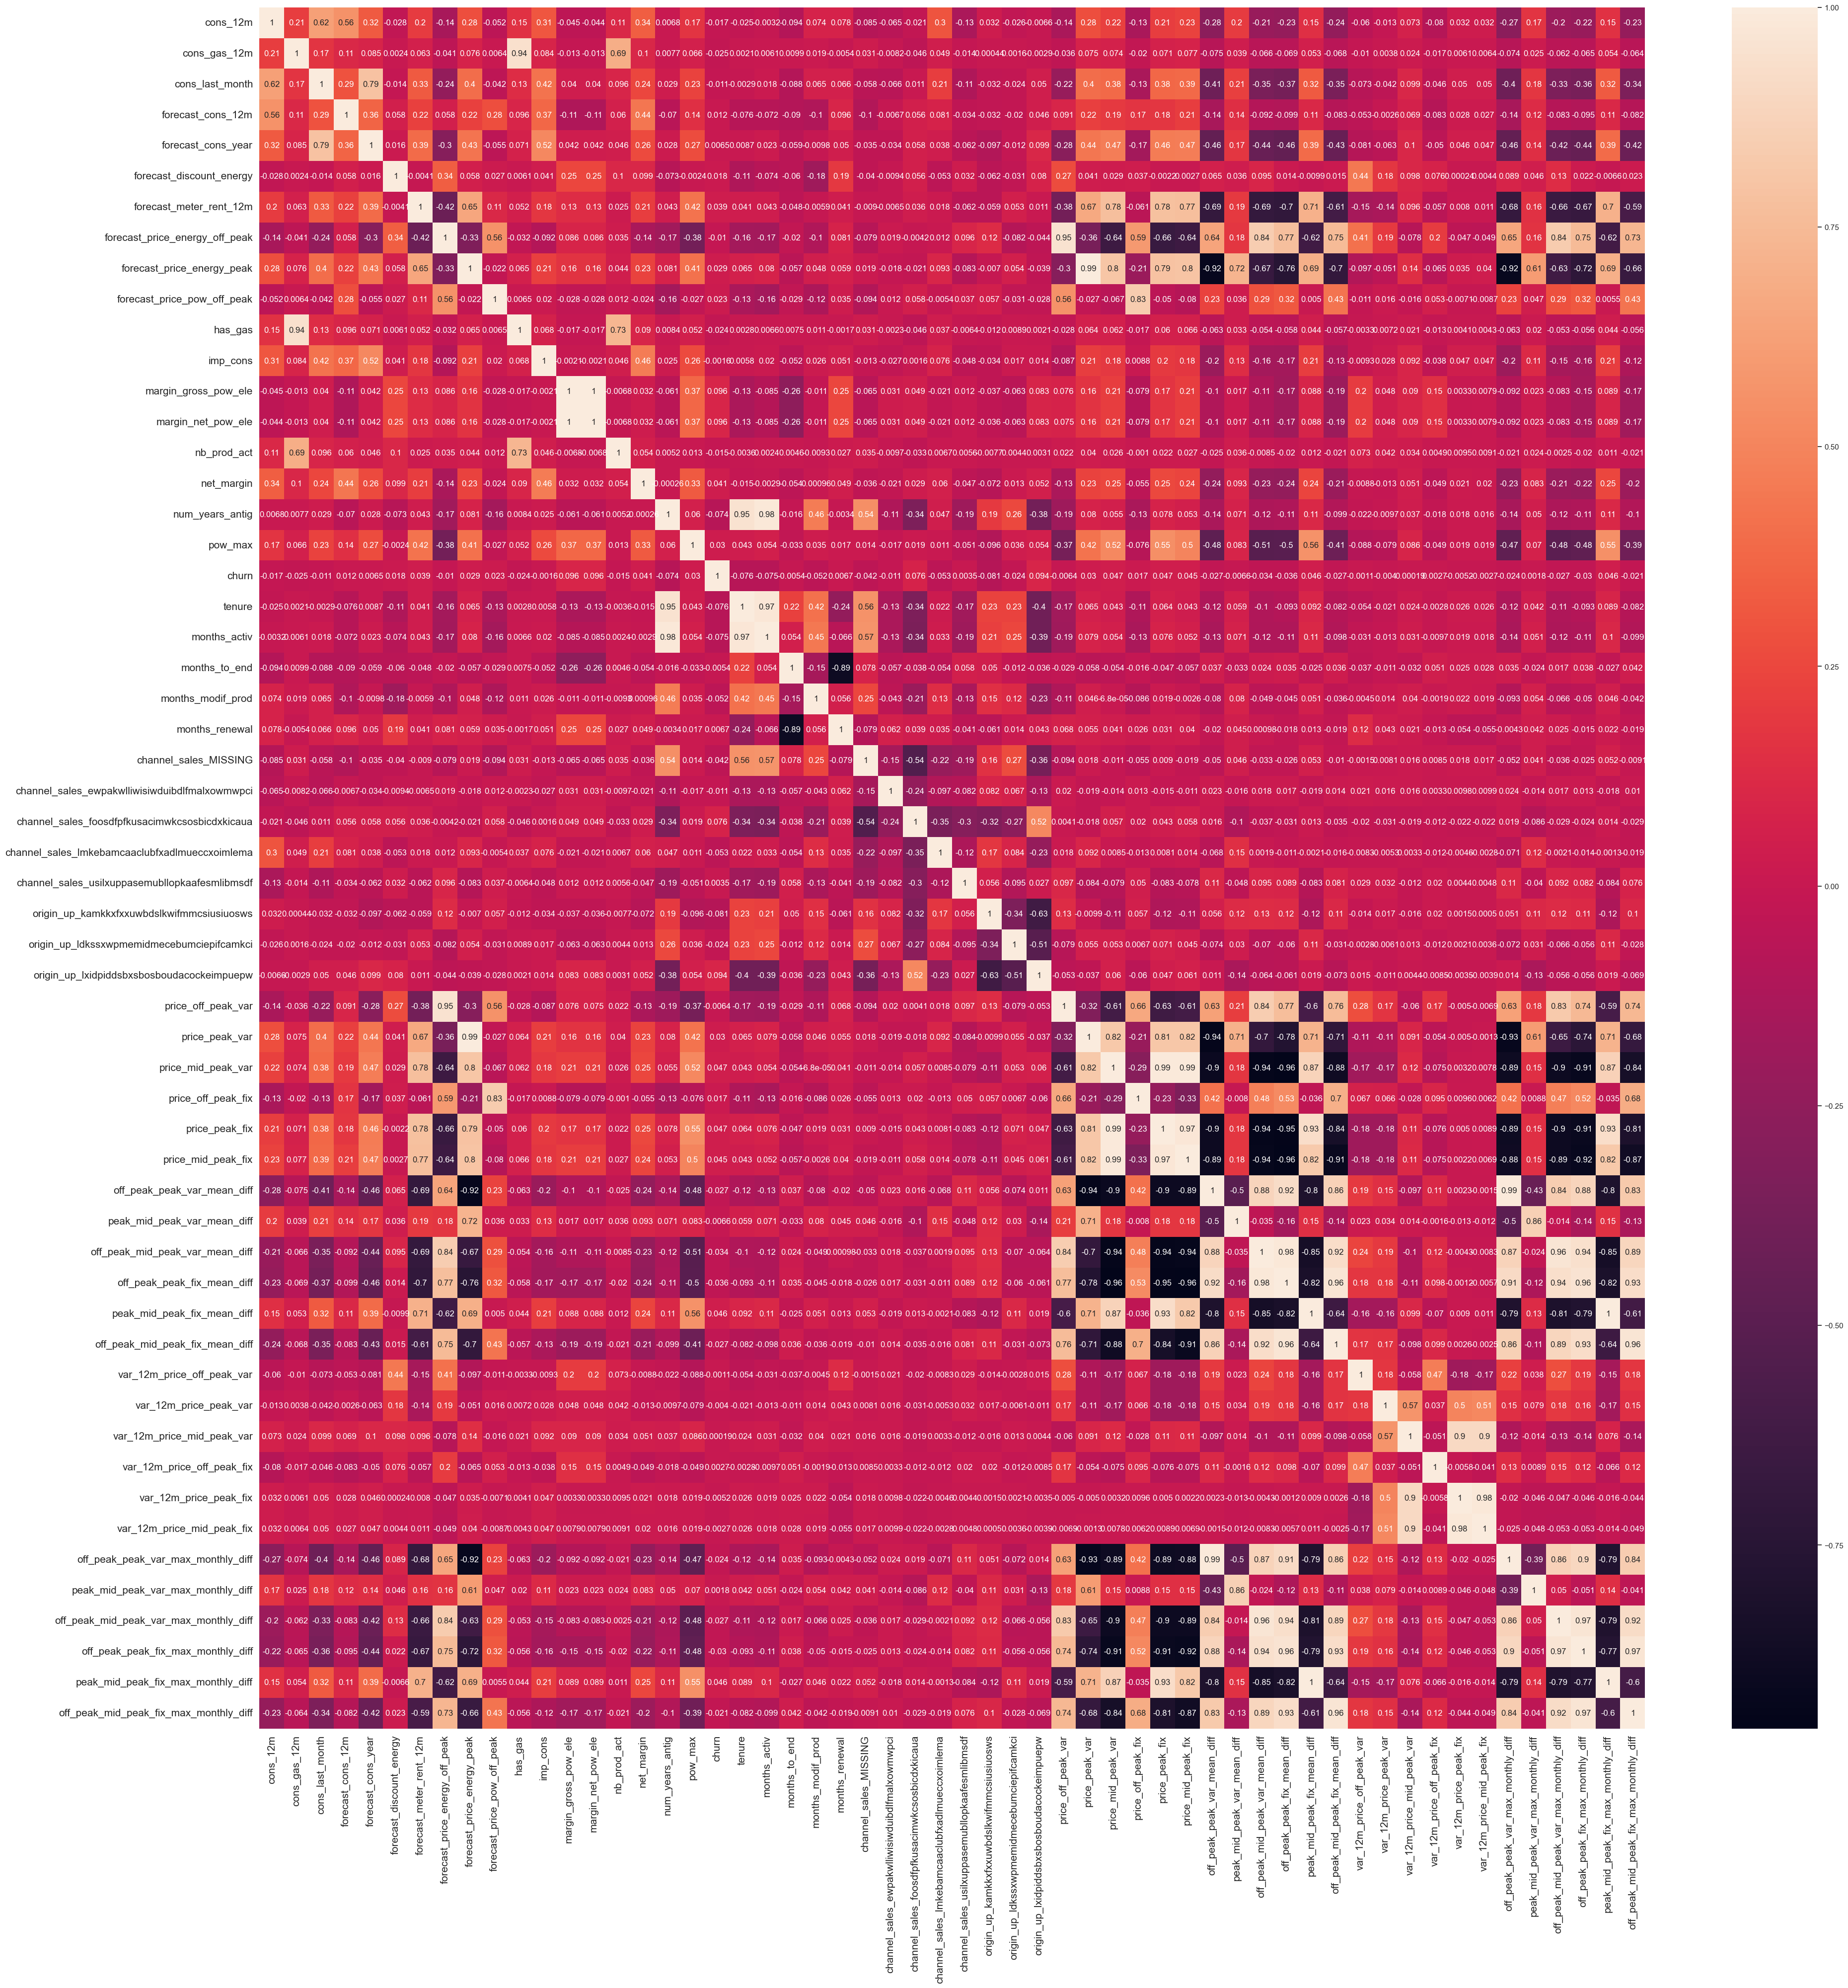

In [55]:
# Plot correlation
plt.figure(figsize=(45, 45))
sns.heatmap(
    correlation, 
    xticklabels=correlation.columns.values,
    yticklabels=correlation.columns.values, 
    annot=True, 
    annot_kws={'size': 12}
)
# Axis ticks size
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.show()


> Since we are specifically going to be making use of the RandomForest model, we do not need to remove highly correlated features solely because of multicollinearity. As a tree-based model, Random Forest is generally less sensitive to multicollinearity.


In [56]:
engineered_df.describe()

,cons_12m,cons_gas_12m,cons_last_month,forecast_cons_12m,forecast_cons_year,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,forecast_price_pow_off_peak,...,var_12m_price_mid_peak_var,var_12m_price_off_peak_fix,var_12m_price_peak_fix,var_12m_price_mid_peak_fix,off_peak_peak_var_max_monthly_diff,peak_mid_peak_var_max_monthly_diff,off_peak_mid_peak_var_max_monthly_diff,off_peak_peak_fix_max_monthly_diff,peak_mid_peak_fix_max_monthly_diff,off_peak_mid_peak_fix_max_monthly_diff
count,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,...,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000
mean,4.223939,0.779244,2.264646,2.962177,1.784610,0.050918,1.517203,0.055766,0.020918,1.636058,...,0.000480,0.278495,-0.046053,-0.025828,0.094262,0.029431,0.119895,34.279812,3.414798,37.446785
std,0.884515,1.717071,1.769305,0.683592,1.584986,0.267388,0.571481,0.009438,0.020296,0.134237,...,0.007119,1.349231,2.186263,1.423582,0.061457,0.033006,0.052129,13.857335,4.864716,10.267419
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-0.098720,-44.266931,-36.344726,-16.724389,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.754023,0.000000,0.000000,2.695477,0.000000,0.000000,1.235023,0.047796,0.000000,1.619163,...,0.000000,0.000004,0.000000,0.000000,0.022581,0.000000,0.054659,16.291555,0.000000,24.437330
50%,4.149727,0.000000,2.899547,3.046836,2.498311,0.000000,1.296555,0.058109,0.035085,1.656207,...,0.000000,0.162916,0.000000,0.000000,0.084587,0.031859,0.149555,44.266931,0.000000,44.444710
75%,4.610285,0.000000,3.529430,3.380716,3.242231,0.000000,2.120673,0.059316,0.040933,1.656207,...,0.000718,0.177779,0.097749,0.065166,0.151367,0.033743,0.152445,44.444710,8.145775,44.444710
max,6.792889,6.618528,5.887169,4.918575,5.243970,1.491362,2.778376,0.105157,0.077722,1.780075,...,0.103502,40.728885,36.490689,16.791555,0.280700,0.229788,0.280700,59.444710,28.122958,59.444710


---
### Seperating Features from Target

In [57]:
X = engineered_df.drop(columns= ['id','churn'])
y = engineered_df['churn']

----
### Model Selection and Training

For this task the Random Forest model was requested.

In [58]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2,
    random_state=42,
    stratify=y
)

To address the class imbalance, we will set the model's `class_weight` parameter to `'balanced'`, giving greater weight to the minority class.

In [59]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

rf = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)



rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

---
Before proceeding with model evaluation and feature importance we must set the appropriate parameters to ensure that our model is accurately catching the customers who actually churn. 
therefore we shall set up Cross Validation and hyperparameter tuning

In [60]:
# We use StratifiedKFold due to the severe class imbalance
from sklearn.model_selection import StratifiedKFold
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [61]:
# Define Hyperparameter
param_grid = {
    "n_estimators": [200, 300, 500],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

In [62]:
# Run RandomizedSearchCV to optimize for F1
from sklearn.model_selection import RandomizedSearchCV
rf_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_grid,
    n_iter=20,
    scoring="f1",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_search.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [None, 10, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.

In [63]:
print("Best parameters:")
print(rf_search.best_params_)

print("\nBest cross-validation F1:")
print(rf_search.best_score_)

Best parameters:
{'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 10}

Best cross-validation F1:
0.26893259563652194


In [64]:
# initialise the tuned model
best_rf = rf_search.best_estimator_

---
### Model Prediction and  Evaluation

In [65]:
# Evaluate the model on the test set
y_pred = best_rf.predict(X_test)
y_proba = best_rf.predict_proba(X_test)[:, 1]

In [66]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.90      0.92      2638
           1       0.29      0.36      0.32       284

    accuracy                           0.85      2922
   macro avg       0.61      0.63      0.62      2922
weighted avg       0.87      0.85      0.86      2922



In [69]:
from sklearn.metrics import average_precision_score

print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print("PR-AUC:", average_precision_score(y_test, y_proba))

ROC-AUC: 0.6888861600230648
PR-AUC: 0.27343517209010115


In [70]:
# Identify the best threshold with the highest F1 score for churn
thresholds = np.arange(0.10, 0.61, 0.05)

threshold_results = []

for threshold in thresholds:

    y_pred_threshold = (y_proba >= threshold).astype(int)

    threshold_results.append({
        "threshold": threshold,
        "precision": precision_score(y_test, y_pred_threshold),
        "recall": recall_score(y_test, y_pred_threshold),
        "f1": f1_score(y_test, y_pred_threshold)
    })

threshold_results = pd.DataFrame(threshold_results)

threshold_results.sort_values(
    "f1",
    ascending=False
).head(10)

,threshold,precision,recall,f1
8,0.50,0.286119,0.355634,0.317111
7,0.45,0.224779,0.447183,0.299176
9,0.55,0.365079,0.242958,0.291755
6,0.40,0.176056,0.528169,0.264085
5,0.35,0.149569,0.672535,0.244715
4,0.30,0.124865,0.813380,0.216495
10,0.60,0.464286,0.137324,0.211957
3,0.25,0.107264,0.894366,0.191554
2,0.20,0.102574,0.968310,0.185497
1,0.15,0.101257,0.992958,0.183773


In [71]:
best_threshold = threshold_results.loc[
    threshold_results["f1"].idxmax(),
    "threshold"
]

print("Best threshold:", best_threshold)

Best threshold: 0.5000000000000001


In [72]:
threshold_results.sort_values(
    "f1",
    ascending=False
).head(10)

,threshold,precision,recall,f1
8,0.50,0.286119,0.355634,0.317111
7,0.45,0.224779,0.447183,0.299176
9,0.55,0.365079,0.242958,0.291755
6,0.40,0.176056,0.528169,0.264085
5,0.35,0.149569,0.672535,0.244715
4,0.30,0.124865,0.813380,0.216495
10,0.60,0.464286,0.137324,0.211957
3,0.25,0.107264,0.894366,0.191554
2,0.20,0.102574,0.968310,0.185497
1,0.15,0.101257,0.992958,0.183773


---
### Feature Importance

In [73]:
feature_importance = (pd.DataFrame({
        "Feature": X.columns,
        "Importance": best_rf.feature_importances_
    })
    .sort_values("Importance", ascending=False)
)

feature_importance.head(20)


,Feature,Importance
12,margin_gross_pow_ele,0.072326
13,margin_net_pow_ele,0.071042
0,cons_12m,0.050929
6,forecast_meter_rent_12m,0.044438
2,cons_last_month,0.040953
15,net_margin,0.037096
19,months_activ,0.034368
3,forecast_cons_12m,0.033865
21,months_modif_prod,0.032380
37,off_peak_peak_var_mean_diff,0.029019


#### Plot the Top 20 Features


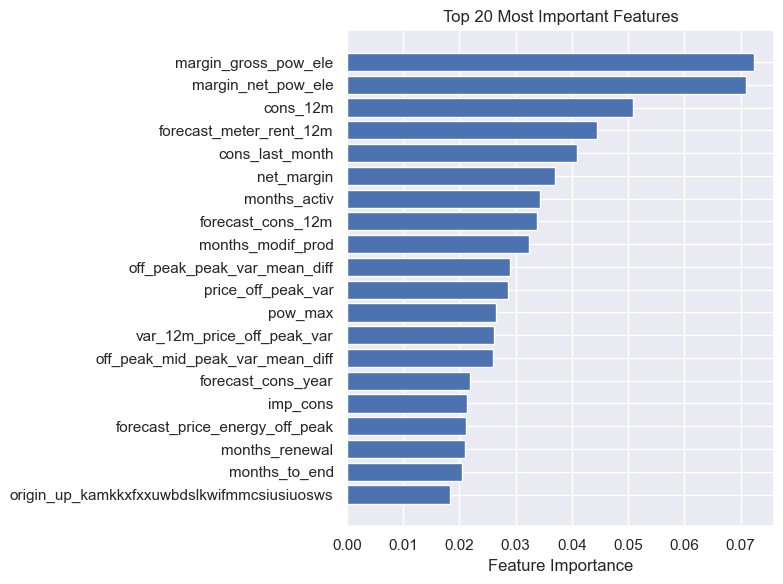

In [74]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(20)

plt.figure(figsize=(8, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.gca().invert_yaxis()

plt.xlabel("Feature Importance")
plt.title("Top 20 Most Important Features")

plt.tight_layout()
plt.show()

From this chart, we can observe the following points:

- Net margin and consumption patterns over 12 months is a top driver for churn in this model
- Margin on power subscription also is an influential driver
>- Time seems to be an influential factor, especially the number of months they have been active, their tenure and the number of months since they updated their contract
>- The feature that our colleague recommended is in the top half in terms of how influential it is and some of the features built off the back of this actually outperform it
- Our price sensitivity features are scattered around but are not the main driver for a customer churning

This last observation is very important because it relates to our primary investigation:

    > Is churn driven by the customers' price sensitivity?

Based on the output of the feature importances, it is not a main driver but it is a weak contributor. However, to arrive at a conclusive result, more experimentation is needed.

### Full Feature Importance Report

The model relies heavily on customer value, profitability and consumption behaviour when distinguishing churners from non-churners.


The customer's net margin contains substantial predictive information about whether they churn but we cannot conclude on if it is the high-margin customers that churn more or not. We will need to investigate further to determine the direction of the relationship seperately to be certain.    
>*Does increasing this variable `'Gross and net margin'` increase churn*

Also, considering that one might think that High-margin customers are more price-sensitive we'll need to investigate the relationship between `'margin', 'price sensitivity' & 'churn'`



Amongst the top 10 churn determining features are those features that describes consumption behaviour such as `cons_12m, forecast_cons_12m, cons_last_month`

This tells us that the amount of electricity a customer consumes and how their consumption changes/is expected to change is strongly associated with churn prediction.  Again, though the result doesn't explicitly tell us whether high consumption increases or decreases churn.  


Finally, looking at our price-related variables, though they arent amongst the strongest predictors they are also quite relevant, particularly the off peak variable charges. 


Among the price variables considered by the Random Forest, the off-peak variable pricing appears to contain more predictive information about churn than peak or mid-peak variable pricing.  This could potentially indicate that customers' churn behaviour is more strongly associated with changes in their off-peak variable tariff than with the other pricing periods, suggesting that customers may be particularly responsive to changes in the off-peak component of their electricity tariff.  




#### Overall


The Random Forest model indicates that customer profitability and consumption behaviour are the strongest predictors of churn, with net and gross power margins ranking as the two most influential features. Price-related variables also contribute meaningfully to churn prediction, particularly the off-peak variable price, differences between tariff periods, and 12-month price variation. This suggests that price dynamics contain useful information for predicting churn, although they appear to be less influential than customer profitability and consumption characteristics. Because Random Forest feature importance does not indicate the direction or causal effect of a variable, further analysis is required to determine whether larger price increases are actually associated with higher churn probability.

Customers generating higher gross and net margins may represent more valuable accounts and could therefore be attractive targets for competitors. If these customers are also highly sensitive to price changes, they may be particularly vulnerable to competitive offers and consequently more likely to churn.

**Further Analysis:** SHAP is particularly useful for this, because unlike the Random Forest's built-in feature importance, SHAP can show both how important a feature is and the direction in which it pushes the model's prediction.

In [75]:
pip install shap

Note: you may need to restart the kernel to use updated packages.


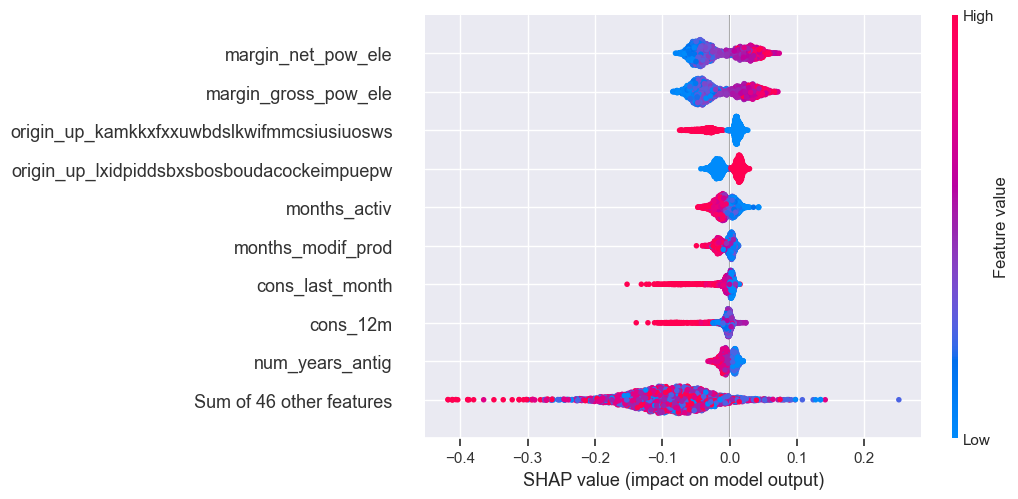

In [76]:
import matplotlib.pyplot as plt
import shap

# 2. Create the TreeExplainer specifically for the Random Forest model
explainer = shap.TreeExplainer(best_rf)

# 3. Calculate the SHAP values
# Random Forest outputs probabilities for both classes [Stay, Churn].
# We grab index [..., 1] to focus purely on what causes CHURN.
shap_values = explainer(X_test)[..., 1]

# 4. Plot the Beeswarm chart
shap.plots.beeswarm(shap_values)


### SHAP Interpretation, Recommendation & Conclusion:
This SHAP analysis reveals that our model is primarily driven by customer's profitability margins and overall energy consumption volume. High net and gross electricity margins (margin_net_pow_ele and margin_gross_pow_ele) are the single most powerful indicators of churn risk, heavily pushing the model to predict whether a customer will leave. 

This could mean that customers facing higher markups are highly price-sensitive and actively seeking competitors. On the acquisition side, customers onboarded through specific channels also show an elevated risk profile, signaling a potential issue with customer quality or expectations set during onboarding from those sources.

Conversely, high-volume energy consumption acts as the model's strongest anchor for customer retention. Large electricity usage over both the short term (cons_last_month) and long term (cons_12m) generates significant negative SHAP values, heavily pushing predictions away from churn and toward loyalty. When combined with the stabilizing influence of the "Sum of 46 other features," the model demonstrates that baseline customers are generally inclined to stay, unless that stability is disrupted by high pricing margins or low usage volumes. To mitigate this risk, PowerCo should proactively review its high-margin accounts for competitive re-pricing and audit the underperforming onboarding channel.


# Overall summary of Key Findings

The current analysis provides several important findings:

### 1. Price variables contain predictive information

Price-related variables contribute to the Random Forest's churn predictions, indicating that historical pricing information contains useful information for distinguishing customers.

### 2. Off-peak pricing is particularly prominent

Among the price-related variables, features involving the **off-peak variable price** appear more prominently in the model's feature-importance results than several peak and mid-peak variables.

This provides a basis for further investigation of customer sensitivity to off-peak pricing.

### 3. Price changes provide additional information

The inclusion of 12-month price variation features allows the analysis to consider not only the customer's price level but also how their pricing changed over time.

This provides a more direct representation of potential price sensitivity than using current price levels alone.

### 4. Model performance improved substantially after tuning

Cross-validation and hyperparameter tuning improved churn recall from **10% to 36%** and increased the churn F1-score from **17% to 32%**.

### 5. There is a substantial precision-recall trade-off

Lowering the classification threshold increases the number of churners identified but also increases false positives.

At a threshold of 0.30, churn recall increases to approximately 81%, while precision falls to approximately 12.5%.


## Save the Result

#### Create and save a new table containing 'churn' and 'churn_probability' columns


In [81]:
test_ids = engineered_df.loc[X_test.index, "id"]

In [82]:
predictions = best_rf.predict(X_test)

probabilities = best_rf.predict_proba(X_test)[:, 1]


results = pd.DataFrame({
    "id": test_ids.values,
    "actual_churn": y_test.values,
    "predicted_churn": predictions,
    "churn_probability": probabilities
})


In [83]:
# Ensure the directory still exists
data_path.mkdir(parents=True, exist_ok=True)

# 2. Save the file
results.to_csv(
    data_path / "sample_prediction_results.csv",
    index=False
)
print('Results Dataframe Sucessfully Exported')

Results Dataframe Sucessfully Exported


* id = client company identifier   
* activity_new = category of the company’s activity  
* channel_sales = code of the sales channel ??? How does customer churn vary across various channels. what are the channels with the major churn  


* date_activ = date of activation of the contract 
* num_years_antig = antiquity of the client (in number of years) 
* date_end = registered date of the end of the contract 
* date_modif_prod = date of the last modification of the product 
* date_renewal = date of the next contract renewal 

* has_gas = indicated if client is also a gas client ??? Does gas partronage have any relationship with churn rates
* nb_prod_act = number of active products and services 


* origin_up = code of the electricity campaign the customer first subscribed to 
* pow_max = subscribed power 




* imp_cons = current paid consumption 
* margin_gross_pow_ele = gross margin on power subscription 
* margin_net_pow_ele = net margin on power subscription 
* net_margin = total net margin 


* cons_12m = electricity consumption of the past 12 months 
* cons_gas_12m = gas consumption of the past 12 months 
* cons_last_month = electricity consumption of the last month



* forecast_cons_12m = forecasted electricity consumption for next 12 months 
* forecast_cons_year = forecasted electricity consumption for the next calendar year 
* forecast_discount_energy = forecasted value of current discount 
* forecast_meter_rent_12m = forecasted bill of meter rental for the next 2 months 
* forecast_price_energy_off_peak = forecasted energy price for 1st period (off peak) 
* forecast_price_energy_peak = forecasted energy price for 2nd period (peak) 
* forecast_price_pow_off_peak = forecasted power price for 1st period (off peak) 




`Author: CHIGOZIE OKONKWO`

`Electrical Engineer | Data Science | PowerCo_Churn`    
* [Github](github.com/GotZie)
* [LinkedIn](linkedin.com/in/chigozie-okonkwo)




<!-- `Author: CHIGOZIE OKONKWO`

`Electrical Engineer | Data Science | PowerCo_Churn`    
* [Github](github.com/GotZie)
* [LinkedIn](linkedin.com/in/chigozie-okonkwo)>